# Convección - difusión en una dimensión - estado estacionario

In [1]:
%matplotlib inline

In [2]:
import numpy as np
from matplotlib import pyplot as plt

## Parámetros

In [3]:
L  = 1.0           # longitud del sistema 1D
nx = 42            # nodos espaciales
dx = L / (nx-2)    # sí, quitamos dos nodos ...
x = np.linspace( 0 , L , num=nx )

c = 2                # velocidad convectiva
D = 1              # difusividad

### Número de Péclet

In [5]:
Pe = c * L / D
Pe

2.0

### Álgebra lineal !

In [27]:
u = np.zeros( nx + 2  )

In [28]:
u[ 1 : nx + 1 ] = u0

In [29]:
u[0] = 1

In [30]:
un = u.copy()         # distribución actual

for i in range( 1 , nx +1 ):
   u[i] = un[i] + Co_D * (un[i+1] + un[i-1] - 2 * un[i] ) - Co  * (un[i] - un[i-1])


El vector uf recibe la solución final, y le quitamos los dos extremos:

In [31]:
uf = u[ 1 : nx +1 ]

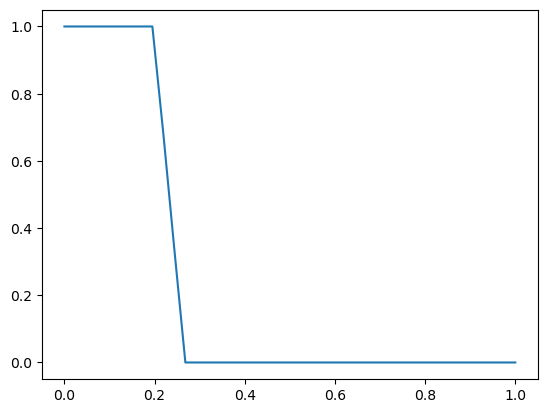

In [32]:
plt.plot( x , uf)

### Tiempo completo

In [51]:
c = 10                # velocidad convectiva
D = 1              # difusividad

In [52]:
Co_D = D * dt / dx**2
Co = c * dt / dx
Pe = c * L / D

print('Co_diff = ', Co_D, ' CFL = ', Co, ' Pe = ',Pe)

Co_diff =  0.31999999999999995  CFL =  0.08  Pe =  10.0


In [53]:
u[ 0 ] = 1
u[ nx + 1 ] = 0
u[ 1 : nx +1 ] = u0

In [54]:
for n in range(nt ):
    un = u.copy()
    for i in range( 1 , nx +1 ): 
           u[i] = un[i] + Co_D * (un[i+1] + un[i-1] - 2 * un[i] ) - Co  * (un[i] - un[i-1])

In [55]:
uf = u[ 1 : nx +1 ]

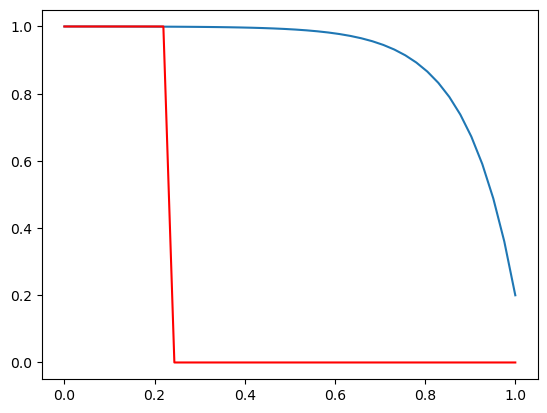

In [56]:
plt.plot(x , uf , x , u0 , 'r')

In [57]:
def solucion_analitica(x, P) :
    u = 0 * x
    i = 0
    eP = np.exp(P)
    for xx in x:
        u[i] = (eP - np.exp( P * xx ))/(eP - 1)
        i += 1

    return u

In [58]:
sol = solucion_analitica(x, Pe )

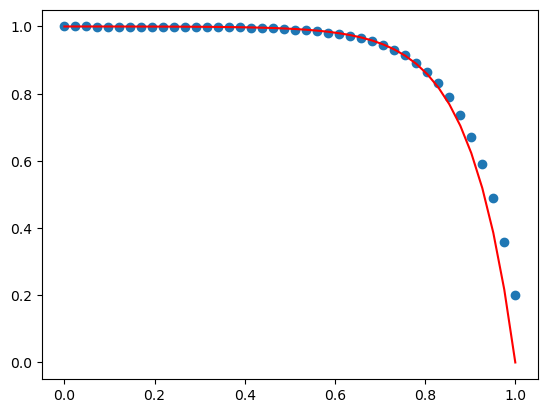

In [59]:
plt.plot(x , uf , 'o', x , sol , 'r')